In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1.1 · Imports & Dataset Load
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9
})

# ── Load ──
df_raw = pd.read_csv("bescom_syn.csv")
df_raw.columns = df_raw.columns.str.strip()

print("=" * 60)
print("  DATASET LOADED")
print("=" * 60)
print(f"  Rows    : {df_raw.shape[0]:,}")
print(f"  Columns : {df_raw.shape[1]}")
print(f"  Memory  : {df_raw.memory_usage(deep=True).sum()/1024:.1f} KB")
print()
print("Column inventory:")
for col in df_raw.columns:
    dtype  = str(df_raw[col].dtype)
    nuniq  = df_raw[col].nunique()
    sample = df_raw[col].iloc[0]
    print(f"  {col:<25} dtype={dtype:<10} unique={nuniq:<6} sample={sample}")

  DATASET LOADED
  Rows    : 10,000
  Columns : 25
  Memory  : 1953.3 KB

Column inventory:
  hist_avg_units            dtype=float64    unique=8222   sample=211.69
  hist_trend                dtype=float64    unique=6456   sample=43.76
  entitlement_limit         dtype=float64    unique=1969   sample=200.0
  num_people                dtype=int64      unique=7      sample=5
  days_home                 dtype=int64      unique=16     sample=22
  month_sin                 dtype=float64    unique=7      sample=-0.5
  month_cos                 dtype=float64    unique=7      sample=-0.866025
  baseload_kwh              dtype=float64    unique=389    sample=221.1
  ac_1ton_kwh               dtype=float64    unique=1007   sample=0.0
  ac_1_5ton_kwh             dtype=float64    unique=1291   sample=0.0
  geyser_kwh                dtype=float64    unique=2976   sample=0.0
  wm_kwh                    dtype=float64    unique=38     sample=6.93
  microwave_kwh             dtype=float64    unique=22

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 1.2 · Data Source Profile
# ─────────────────────────────────────────────────────────────
print("Sample Records (first 5):")
display(df_raw.head(5))

print("\nDescriptive Statistics:")
display(df_raw.describe().round(2))

print("\nColumn Groups:")
print("  Training features (22):")
TRAINING_FEATURES = [
    'hist_avg_units', 'hist_trend', 'entitlement_limit',
    'num_people', 'days_home', 'month_sin', 'month_cos',
    'baseload_kwh',
    'ac_1ton_kwh', 'ac_1_5ton_kwh', 'geyser_kwh',
    'wm_kwh', 'microwave_kwh', 'cooler_kwh', 'iron_kwh',
    'has_ac_1ton', 'has_ac_1_5ton', 'has_geyser',
    'has_wm', 'has_microwave', 'has_cooler', 'has_iron'
]
for f in TRAINING_FEATURES:
    print(f"    {f}")

print("\n  Audit columns (NOT used in training):")
AUDIT_COLS = ['month', 'theoretical_units']
for a in AUDIT_COLS:
    print(f"    {a}")

print("\n  Target variable:")
print("    actual_units  ← monthly kWh (real-world, deviates from formula)")

Sample Records (first 5):


,hist_avg_units,hist_trend,entitlement_limit,num_people,days_home,month_sin,month_cos,baseload_kwh,ac_1ton_kwh,ac_1_5ton_kwh,...,has_ac_1ton,has_ac_1_5ton,has_geyser,has_wm,has_microwave,has_cooler,has_iron,month,theoretical_units,actual_units
0,211.69,43.76,200.0,5,22,-0.500000,-0.866025,221.10,0.00,0.0,...,0,0,0,1,1,0,1,7,265.41,210.62
1,269.16,-20.71,200.0,4,18,0.866025,-0.500000,208.32,113.54,0.0,...,1,0,0,1,0,0,0,4,325.32,244.50
2,201.01,-20.02,200.0,5,30,0.866025,0.500000,236.10,0.00,0.0,...,0,0,0,0,0,0,1,2,242.27,206.50
3,198.17,2.82,200.0,4,30,0.500000,0.866025,221.70,0.00,0.0,...,0,0,0,0,0,0,1,1,227.55,177.93
4,182.02,22.29,200.0,4,25,-0.500000,0.866025,143.46,0.00,0.0,...,0,0,1,1,0,0,1,11,198.90,189.76



Descriptive Statistics:


,hist_avg_units,hist_trend,entitlement_limit,num_people,days_home,month_sin,month_cos,baseload_kwh,ac_1ton_kwh,ac_1_5ton_kwh,...,has_ac_1ton,has_ac_1_5ton,has_geyser,has_wm,has_microwave,has_cooler,has_iron,month,theoretical_units,actual_units
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,...,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,247.36,-0.08,191.33,3.70,25.67,0.01,0.01,203.57,15.22,37.19,...,0.1,0.13,0.38,0.40,0.30,0.12,0.85,6.48,291.11,247.59
std,105.57,28.20,23.00,1.39,4.09,0.71,0.71,49.44,49.34,104.45,...,0.3,0.34,0.49,0.49,0.46,0.32,0.36,3.47,123.28,100.30
min,35.82,-99.17,39.40,1.00,15.00,-1.00,-1.00,30.60,0.00,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,48.53,29.12
25%,184.17,-19.03,200.00,3.00,23.00,-0.50,-0.50,180.96,0.00,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,1.00,3.00,217.91,182.60
50%,217.56,-0.14,200.00,4.00,27.00,0.00,-0.00,203.46,0.00,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,254.54,228.26
75%,280.64,18.77,200.00,5.00,30.00,0.87,0.87,225.96,0.00,0.00,...,0.0,0.00,1.00,1.00,1.00,0.00,1.00,10.00,329.64,292.29
max,757.14,117.12,200.00,7.00,30.00,1.00,1.00,391.32,318.71,633.38,...,1.0,1.00,1.00,1.00,1.00,1.00,1.00,12.00,883.73,988.26



Column Groups:
  Training features (22):
    hist_avg_units
    hist_trend
    entitlement_limit
    num_people
    days_home
    month_sin
    month_cos
    baseload_kwh
    ac_1ton_kwh
    ac_1_5ton_kwh
    geyser_kwh
    wm_kwh
    microwave_kwh
    cooler_kwh
    iron_kwh
    has_ac_1ton
    has_ac_1_5ton
    has_geyser
    has_wm
    has_microwave
    has_cooler
    has_iron

  Audit columns (NOT used in training):
    month
    theoretical_units

  Target variable:
    actual_units  ← monthly kWh (real-world, deviates from formula)


## Part 2 — Exploratory Data Analysis (EDA)
---

In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 2.1 · Data Quality Audit
# ─────────────────────────────────────────────────────────────
df = df_raw.copy()

num_cols = df.select_dtypes(include=np.number).columns

print("─── Quality Audit ───────────────────────────────────")
print(f"  Rows               : {len(df):,}")
print(f"  Columns            : {df.shape[1]}")
print(f"  Missing values     : {df.isnull().sum().sum()}")
print(f"  Duplicate rows     : {df.duplicated().sum()}")
print(f"  Negative values    : {(df[num_cols] < 0).any().any()}")

# Zero-variance check
zero_var = [c for c in df.columns if df[c].nunique() <= 1]
print(f"  Zero-variance cols : {zero_var if zero_var else 'None'}")

print()
print("─── Column Missing Value Detail ─────────────────────")
nulls = df.isnull().sum()
for col in df.columns:
    tag = "✓" if nulls[col] == 0 else f"✗ {nulls[col]} missing"
    print(f"  {col:<25}: {tag}")

print()
print("─── KEY VALIDATION: actual_units ≠ theoretical_units ─")
diff = abs(df['actual_units'] - df['theoretical_units'])
corr = df['theoretical_units'].corr(df['actual_units'])
print(f"  Correlation (theoretical vs actual) : {corr:.4f}")
print(f"  Mean absolute deviation             : {diff.mean():.2f} units")
print(f"  Max deviation                       : {diff.max():.2f} units")
print(f"  % rows where deviation > 20 units  : {(diff>20).mean()*100:.1f}%")
print()
print("  ✓ Correlation < 1.0 confirms model is NOT just learning the formula.")
print("  ✓ Mean deviation proves real-world factors create genuine signal.")

─── Quality Audit ───────────────────────────────────
  Rows               : 10,000
  Columns            : 25
  Missing values     : 0
  Duplicate rows     : 0
  Negative values    : True
  Zero-variance cols : None

─── Column Missing Value Detail ─────────────────────
  hist_avg_units           : ✓
  hist_trend               : ✓
  entitlement_limit        : ✓
  num_people               : ✓
  days_home                : ✓
  month_sin                : ✓
  month_cos                : ✓
  baseload_kwh             : ✓
  ac_1ton_kwh              : ✓
  ac_1_5ton_kwh            : ✓
  geyser_kwh               : ✓
  wm_kwh                   : ✓
  microwave_kwh            : ✓
  cooler_kwh               : ✓
  iron_kwh                 : ✓
  has_ac_1ton              : ✓
  has_ac_1_5ton            : ✓
  has_geyser               : ✓
  has_wm                   : ✓
  has_microwave            : ✓
  has_cooler               : ✓
  has_iron                 : ✓
  month                    : ✓
  theoretical_un

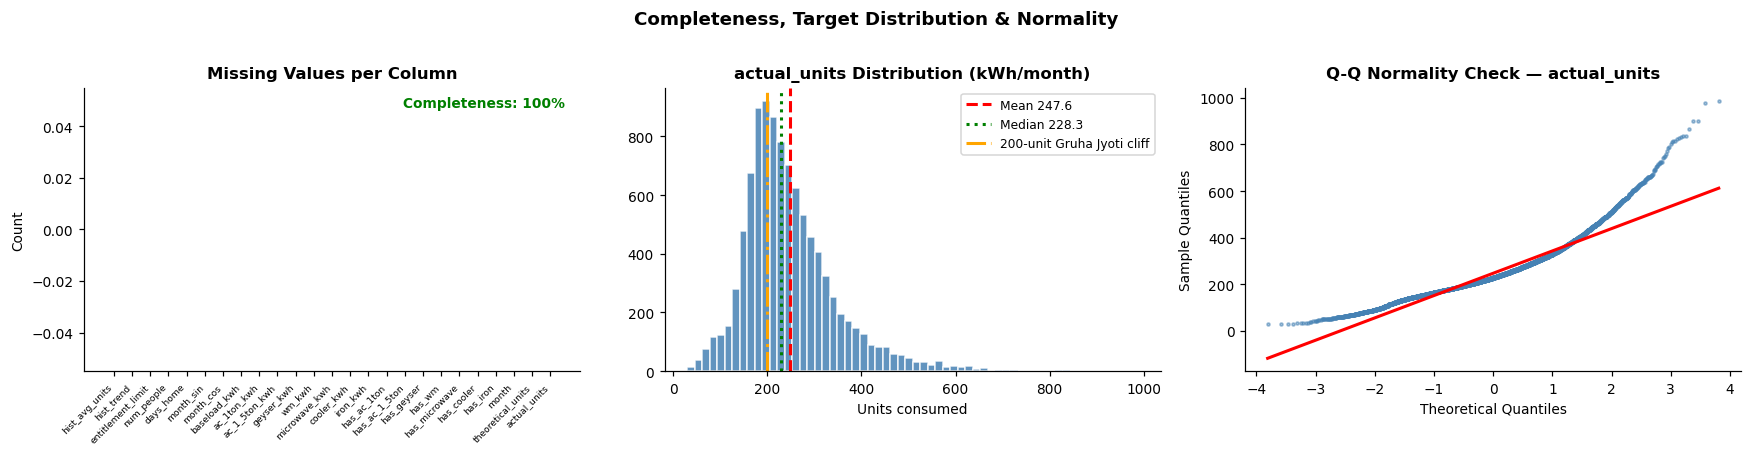

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 2.2 · Missingness, Target Distribution & Normality
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Missing values bar
mv = df.isnull().sum()
axes[0].bar(mv.index, mv.values,
            color=["#e74c3c" if v > 0 else "#2ecc71" for v in mv])
axes[0].set_title("Missing Values per Column", fontweight="bold")
axes[0].set_ylabel("Count")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right", fontsize=6)
axes[0].text(0.97, 0.97, "Completeness: 100%",
             transform=axes[0].transAxes, ha="right", va="top",
             color="green", fontsize=9, fontweight="bold")

# actual_units distribution
axes[1].hist(df["actual_units"], bins=60, color="steelblue",
             edgecolor="white", alpha=0.85)
axes[1].axvline(df["actual_units"].mean(), color="red", lw=2, ls="--",
                label=f"Mean {df['actual_units'].mean():.1f}")
axes[1].axvline(df["actual_units"].median(), color="green", lw=2, ls=":",
                label=f"Median {df['actual_units'].median():.1f}")
axes[1].axvline(200, color="orange", lw=2, ls="-.",
                label="200-unit Gruha Jyoti cliff")
axes[1].set_title("actual_units Distribution (kWh/month)", fontweight="bold")
axes[1].set_xlabel("Units consumed")
axes[1].legend(fontsize=8)

# Q-Q normality check on target
res = stats.probplot(df["actual_units"], dist="norm")
axes[2].plot(res[0][0], res[0][1], "o", color="steelblue", ms=2, alpha=0.5)
axes[2].plot(res[0][0], res[1][0]*res[0][0]+res[1][1], color="red", lw=2)
axes[2].set_title("Q-Q Normality Check — actual_units", fontweight="bold")
axes[2].set_xlabel("Theoretical Quantiles")
axes[2].set_ylabel("Sample Quantiles")

plt.suptitle("Completeness, Target Distribution & Normality",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Outlier Count (IQR method):
  hist_avg_units        :   814 (8.1%)
  hist_trend            :    67 (0.7%)
  baseload_kwh          :  1113 (11.1%)
  ac_1ton_kwh           :  1032 (10.3%)
  ac_1_5ton_kwh         :  1311 (13.1%)
  geyser_kwh            :   774 (7.7%)
  wm_kwh                :   102 (1.0%)
  num_people            :     0 (0.0%)
  days_home             :     0 (0.0%)
  actual_units          :   413 (4.1%)  ← WILL REMOVE (target only)


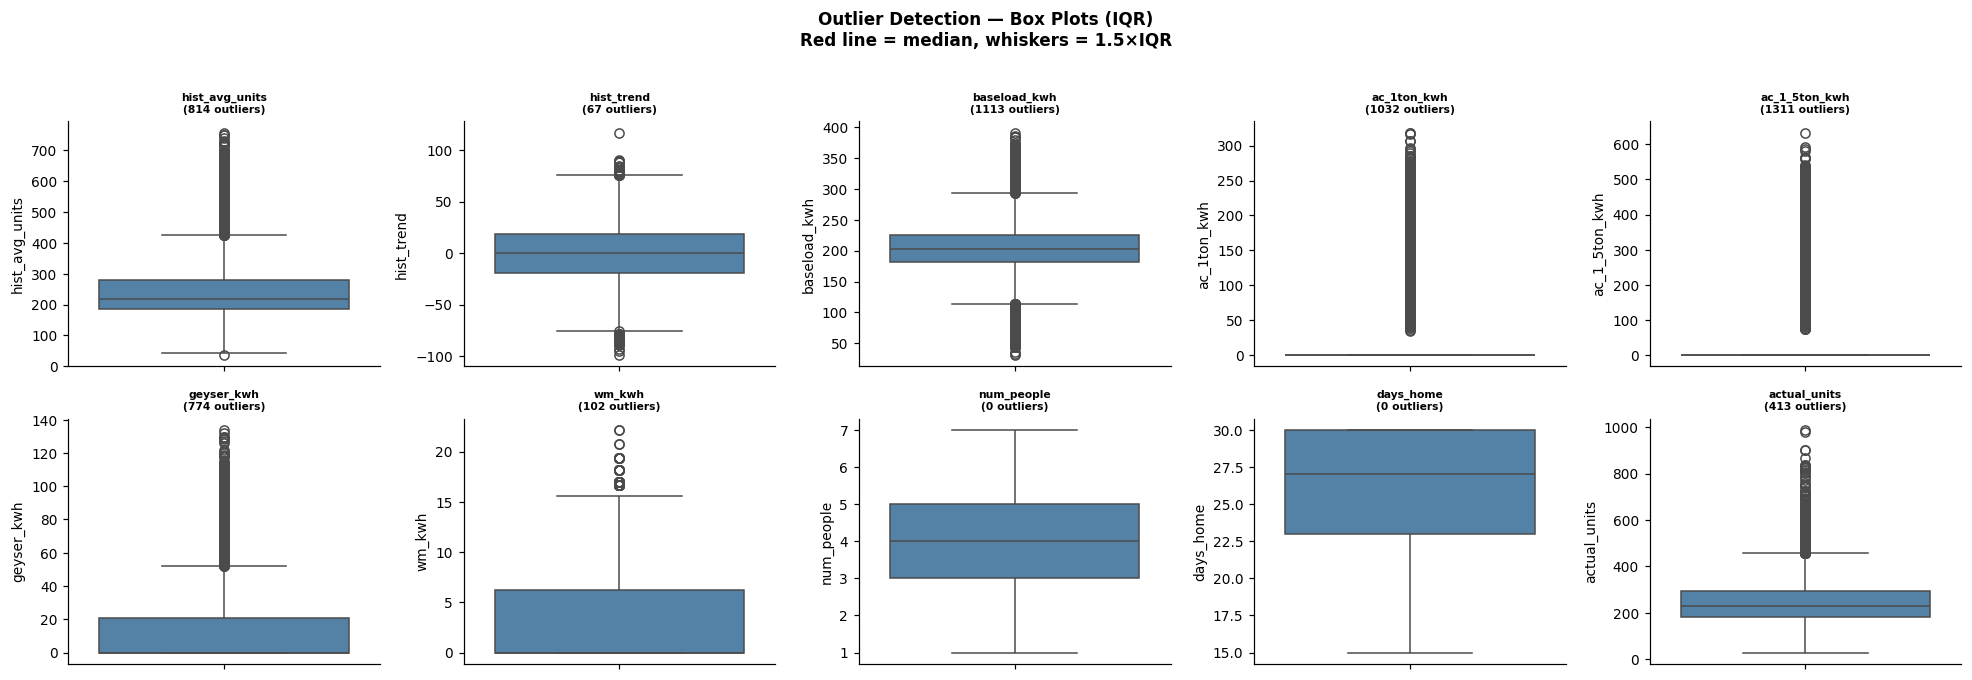

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 2.3 · Outlier Detection — IQR Method on Target
# ─────────────────────────────────────────────────────────────
# IQR applied to actual_units ONLY (target).
# Feature outliers are retained — a household with 5 fans
# and 10 hrs AC is unusual but genuinely real.

key_cols = [
    'hist_avg_units', 'hist_trend', 'baseload_kwh',
    'ac_1ton_kwh', 'ac_1_5ton_kwh', 'geyser_kwh',
    'wm_kwh', 'num_people', 'days_home', 'actual_units'
]

print("Outlier Count (IQR method):")
for col in key_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    action = "  ← WILL REMOVE (target only)" if col == "actual_units" else ""
    print(f"  {col:<22}: {n:>5} ({n/len(df)*100:.1f}%){action}")

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, col in zip(axes.flatten(), key_cols):
    sns.boxplot(y=df[col], ax=ax, color="steelblue")
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    n = ((df[col] < Q1-1.5*(Q3-Q1)) | (df[col] > Q3+1.5*(Q3-Q1))).sum()
    ax.set_title(f"{col}\n({n} outliers)", fontsize=7, fontweight="bold")

fig.suptitle("Outlier Detection — Box Plots (IQR)\nRed line = median, whiskers = 1.5×IQR",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

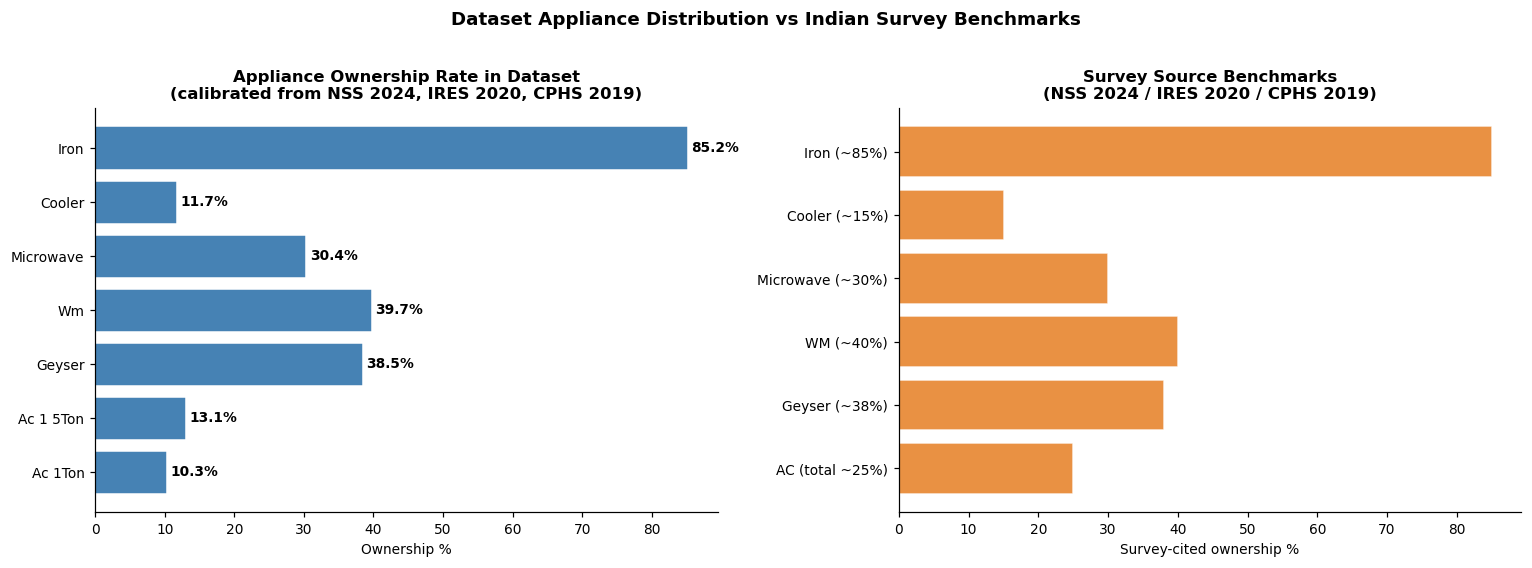

Ownership rates vs survey benchmarks:
  AC (any)    : 23.4%  target: ~25%  [NSS 2024]
  Geyser      : 38.5%  target: ~38%  [IRES 2020]
  WM          : 39.7%  target: ~40%  [CPHS 2019]
  Microwave   : 30.4%  target: ~30%  [IRES 2020]
  Iron        : 85.2%  target: ~85%  [IRES 2020]


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 2.4 · Appliance Ownership Distribution
# ─────────────────────────────────────────────────────────────
binary_flags = [
    'has_ac_1ton', 'has_ac_1_5ton', 'has_geyser',
    'has_wm', 'has_microwave', 'has_cooler', 'has_iron'
]

ownership_pct = {col: df[col].mean()*100 for col in binary_flags}
labels = [c.replace("has_", "").replace("_", " ").title() for c in binary_flags]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ownership bar chart
bars = axes[0].barh(labels, list(ownership_pct.values()),
                    color="steelblue", edgecolor="white")
axes[0].set_xlabel("Ownership %")
axes[0].set_title("Appliance Ownership Rate in Dataset\n"
                  "(calibrated from NSS 2024, IRES 2020, CPHS 2019)",
                  fontweight="bold")
for bar, val in zip(bars, ownership_pct.values()):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")

# Source benchmarks
sources = {
    "AC (total ~25%)": 25, "Geyser (~38%)": 38,
    "WM (~40%)": 40, "Microwave (~30%)": 30,
    "Cooler (~15%)": 15, "Iron (~85%)": 85
}
source_vals = list(sources.values())
source_labels = list(sources.keys())
axes[1].barh(source_labels, source_vals, color="#e67e22", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Survey-cited ownership %")
axes[1].set_title("Survey Source Benchmarks\n(NSS 2024 / IRES 2020 / CPHS 2019)",
                  fontweight="bold")

plt.suptitle("Dataset Appliance Distribution vs Indian Survey Benchmarks",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Ownership rates vs survey benchmarks:")
print(f"  AC (any)    : {(df['has_ac_1ton']|df['has_ac_1_5ton']).mean()*100:.1f}%  target: ~25%  [NSS 2024]")
print(f"  Geyser      : {df['has_geyser'].mean()*100:.1f}%  target: ~38%  [IRES 2020]")
print(f"  WM          : {df['has_wm'].mean()*100:.1f}%  target: ~40%  [CPHS 2019]")
print(f"  Microwave   : {df['has_microwave'].mean()*100:.1f}%  target: ~30%  [IRES 2020]")
print(f"  Iron        : {df['has_iron'].mean()*100:.1f}%  target: ~85%  [IRES 2020]")

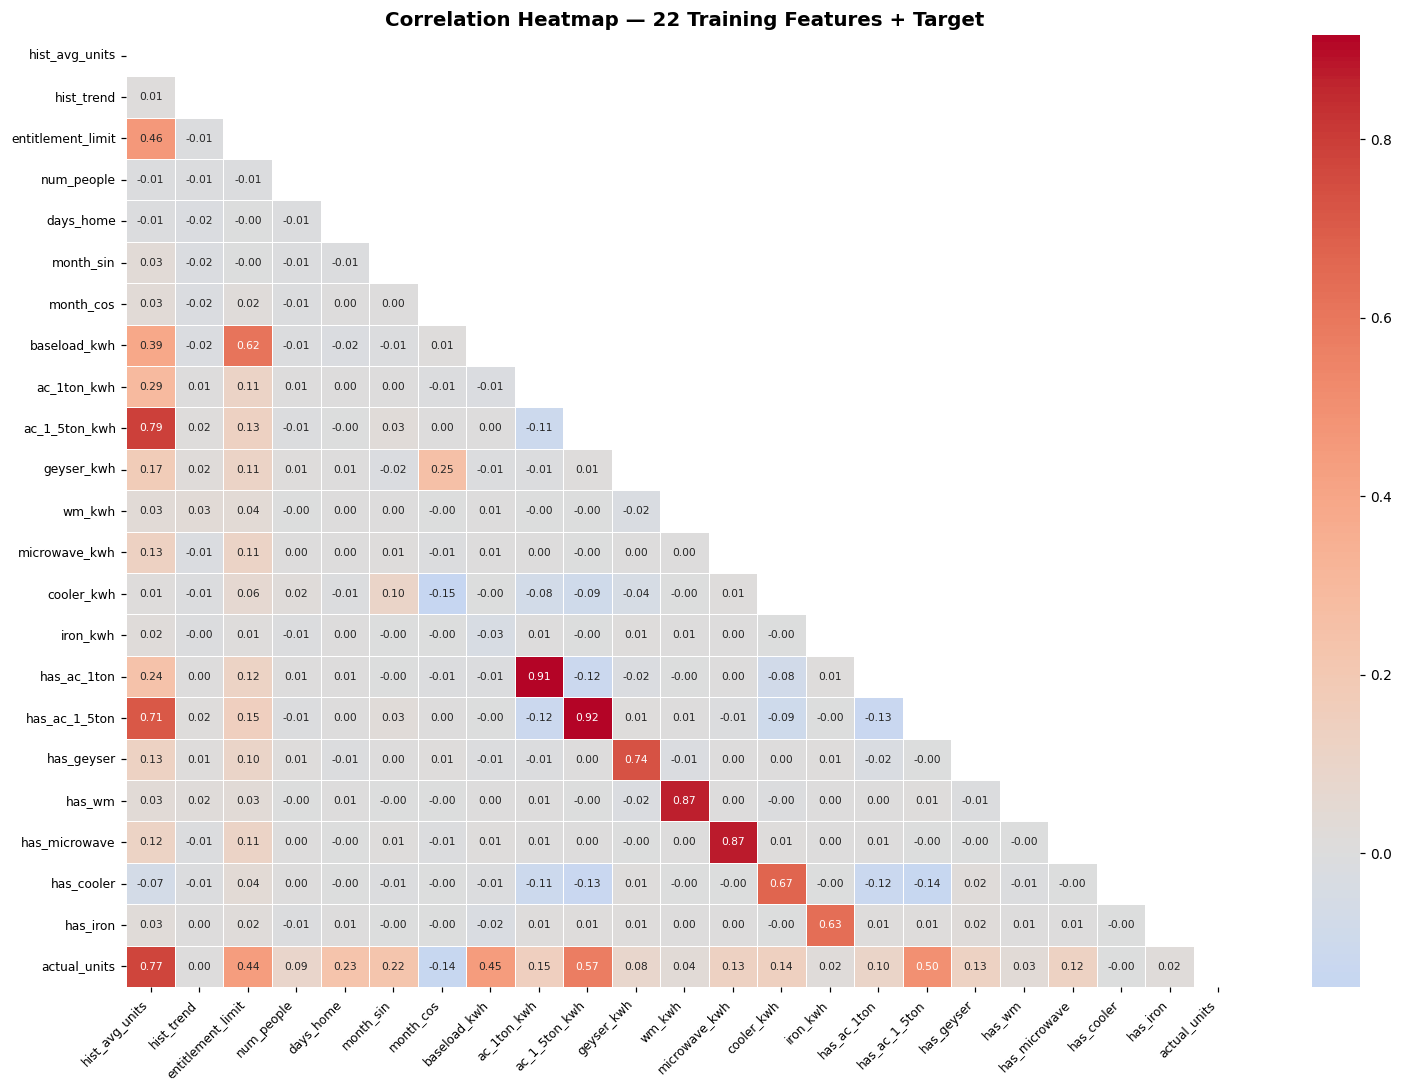

Top correlations with actual_units:
  hist_avg_units           : +0.771  ███████████████████
  ac_1_5ton_kwh            : +0.575  ██████████████
  has_ac_1_5ton            : +0.498  ████████████
  baseload_kwh             : +0.447  ███████████
  entitlement_limit        : +0.440  ██████████
  days_home                : +0.231  █████
  month_sin                : +0.225  █████
  ac_1ton_kwh              : +0.148  ███
  cooler_kwh               : +0.139  ███
  month_cos                : -0.138  ███
  microwave_kwh            : +0.135  ███
  has_geyser               : +0.128  ███
  has_microwave            : +0.123  ███
  has_ac_1ton              : +0.104  ██
  num_people               : +0.089  ██
  geyser_kwh               : +0.084  ██
  wm_kwh                   : +0.035  
  has_wm                   : +0.035  
  has_iron                 : +0.024  
  iron_kwh                 : +0.018  
  has_cooler               : -0.002  
  hist_trend               : +0.001  


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 2.5 · Correlation Heatmap — Training Features vs Target
# ─────────────────────────────────────────────────────────────
# Only training features + target shown.
# Audit columns (month, theoretical_units) excluded.

cols_for_corr = TRAINING_FEATURES + ['actual_units']
corr = df[cols_for_corr].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=0.4, linecolor="white",
            annot_kws={"size": 7})
plt.title("Correlation Heatmap — 22 Training Features + Target",
          fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print("Top correlations with actual_units:")
corr_target = corr["actual_units"].drop("actual_units").sort_values(
    key=abs, ascending=False)
for feat, val in corr_target.items():
    bar = "█" * int(abs(val) * 25)
    print(f"  {feat:<25}: {val:+.3f}  {bar}")

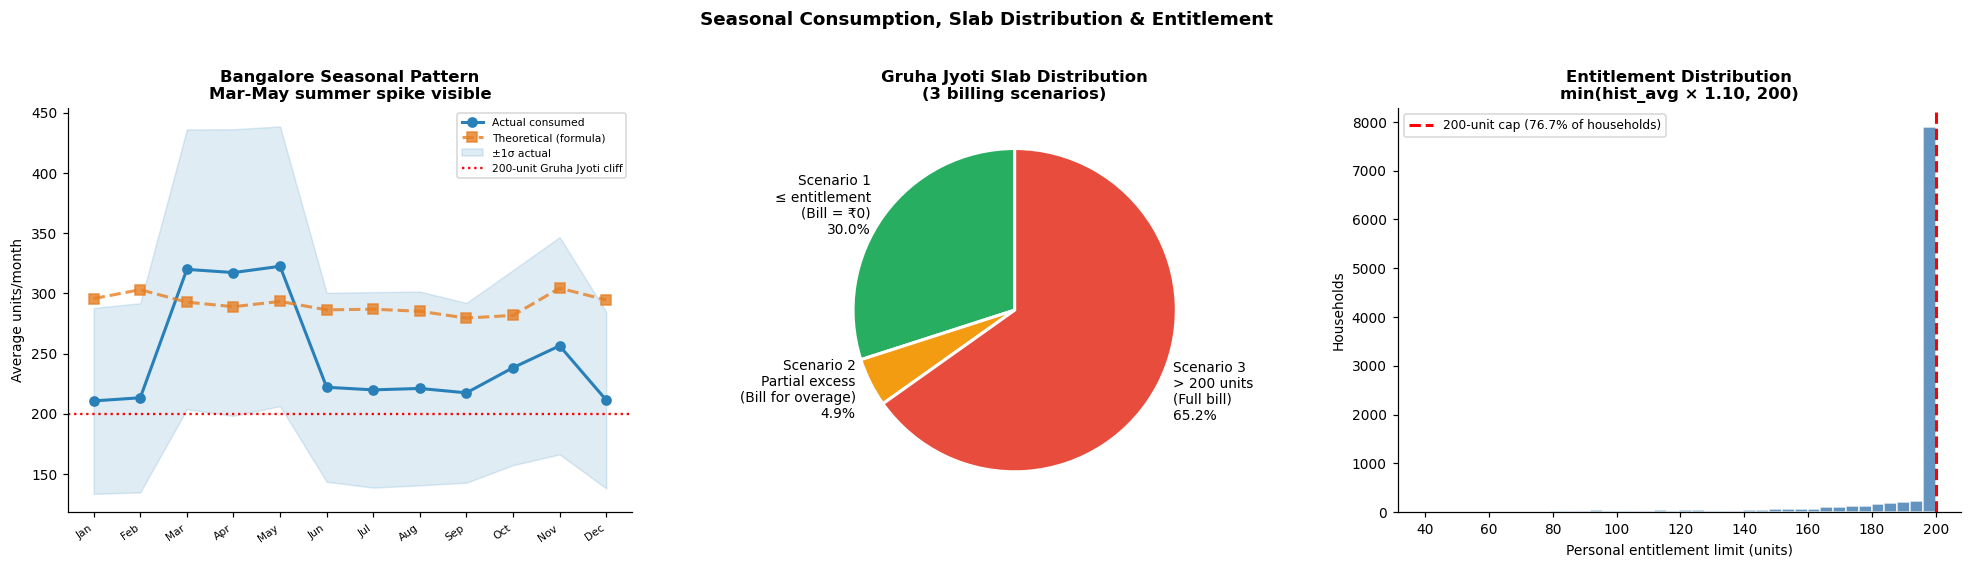

  GRUHA JYOTI SLAB DISTRIBUTION
  Scenario 1 — bill = ₹0 : 2,996  (30.0%)
  Scenario 2 — partial   :   487  (4.9%)
  Scenario 3 — full bill : 6,517  (65.2%)

  Entitlement min        : 39.4 units
  Entitlement mean       : 191.3 units
  Entitlement at cap(200): 76.7%


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 2.6 · Seasonal Pattern & Gruha Jyoti Slab Analysis
# ─────────────────────────────────────────────────────────────
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_actual  = df.groupby('month')['actual_units'].mean()
monthly_theory  = df.groupby('month')['theoretical_units'].mean()
monthly_std     = df.groupby('month')['actual_units'].std()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Seasonal pattern
axes[0].plot(monthly_actual.index, monthly_actual.values,
             marker='o', color='#2980B9', lw=2, label='Actual consumed')
axes[0].plot(monthly_theory.index, monthly_theory.values,
             marker='s', linestyle='--', color='#E67E22', lw=2,
             alpha=0.8, label='Theoretical (formula)')
axes[0].fill_between(monthly_actual.index,
                     monthly_actual.values - monthly_std.values,
                     monthly_actual.values + monthly_std.values,
                     alpha=0.15, color='#2980B9', label='±1σ actual')
axes[0].axhline(200, color='red', linestyle=':', lw=1.5,
                label='200-unit Gruha Jyoti cliff')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=35, ha='right', fontsize=7)
axes[0].set_ylabel('Average units/month')
axes[0].set_title('Bangalore Seasonal Pattern\nMar-May summer spike visible',
                  fontweight='bold')
axes[0].legend(fontsize=7)

# Gruha Jyoti slab split using entitlement
below = (df['actual_units'] <= df['entitlement_limit']).sum()
partial = ((df['actual_units'] > df['entitlement_limit']) &
           (df['actual_units'] <= 200)).sum()
above  = (df['actual_units'] > 200).sum()
total  = len(df)

axes[1].pie(
    [below, partial, above],
    labels=[
        f"Scenario 1\n≤ entitlement\n(Bill = ₹0)\n{below/total*100:.1f}%",
        f"Scenario 2\nPartial excess\n(Bill for overage)\n{partial/total*100:.1f}%",
        f"Scenario 3\n> 200 units\n(Full bill)\n{above/total*100:.1f}%"
    ],
    colors=["#27AE60", "#F39C12", "#E74C3C"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Gruha Jyoti Slab Distribution\n(3 billing scenarios)",
                  fontweight="bold")

# Entitlement distribution
axes[2].hist(df['entitlement_limit'], bins=40, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[2].axvline(200, color='red', lw=2, ls='--',
                label='200-unit cap (76.7% of households)')
axes[2].set_xlabel('Personal entitlement limit (units)')
axes[2].set_ylabel('Households')
axes[2].set_title('Entitlement Distribution\nmin(hist_avg × 1.10, 200)',
                  fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle("Seasonal Consumption, Slab Distribution & Entitlement",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("=" * 55)
print("  GRUHA JYOTI SLAB DISTRIBUTION")
print("=" * 55)
print(f"  Scenario 1 — bill = ₹0 : {below:>5,}  ({below/total*100:.1f}%)")
print(f"  Scenario 2 — partial   : {partial:>5,}  ({partial/total*100:.1f}%)")
print(f"  Scenario 3 — full bill : {above:>5,}  ({above/total*100:.1f}%)")
print(f"\n  Entitlement min        : {df['entitlement_limit'].min():.1f} units")
print(f"  Entitlement mean       : {df['entitlement_limit'].mean():.1f} units")
print(f"  Entitlement at cap(200): {(df['entitlement_limit']>=200).mean()*100:.1f}%")

## Part 3 — Data Preprocessing
---

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 3.1 · Duplicate Removal & Missing Value Verification
# ─────────────────────────────────────────────────────────────
df_clean = df_raw.copy()

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
dupes_removed = before - len(df_clean)

print("Step 1 — Duplicate removal:")
print(f"  Before : {before:,} rows")
print(f"  Removed: {dupes_removed}")
print(f"  After  : {len(df_clean):,} rows")

print()
print("Step 2 — Missing value verification:")
nulls = df_clean.isnull().sum()
print(f"  Total nulls: {nulls.sum()}")
if nulls.sum() == 0:
    print("  ✓ Zero missing values — dataset is complete by design.")
else:
    print("  ✗ Missing values found:")
    print(nulls[nulls > 0])

Step 1 — Duplicate removal:
  Before : 10,000 rows
  Removed: 0
  After  : 10,000 rows

Step 2 — Missing value verification:
  Total nulls: 0
  ✓ Zero missing values — dataset is complete by design.


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 3.2 · IQR Outlier Removal — Target Only (actual_units)
# ─────────────────────────────────────────────────────────────
# Applied ONLY to actual_units (target).
# Reason: Extreme target values are generation artifacts from
# extreme factor combinations, not genuine household records.
# Feature outliers are intentionally retained — a household
# with 5 fans or 9-hr AC is unusual but real. Removing it
# would reduce model generalisability.

Q1  = df_clean['actual_units'].quantile(0.25)
Q3  = df_clean['actual_units'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = len(df_clean)
df_clean = df_clean[
    (df_clean['actual_units'] >= lower) &
    (df_clean['actual_units'] <= upper)
].copy().reset_index(drop=True)

removed = before - len(df_clean)
print("Step 3 — IQR filter on actual_units:")
print(f"  Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
print(f"  Lower fence : {lower:.2f}")
print(f"  Upper fence : {upper:.2f}")
print(f"  Rows before : {before:,}")
print(f"  Removed     : {removed} ({removed/before*100:.2f}%)")
print(f"  Rows after  : {len(df_clean):,}")
print()
print("  Feature outliers: RETAINED (realistic household variation)")
print("  Target outliers : REMOVED  (generation artifacts)")

Step 3 — IQR filter on actual_units:
  Q1=182.60  Q3=292.29  IQR=109.69
  Lower fence : 18.07
  Upper fence : 456.82
  Rows before : 10,000
  Removed     : 413 (4.13%)
  Rows after  : 9,587

  Feature outliers: RETAINED (realistic household variation)
  Target outliers : REMOVED  (generation artifacts)


In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 3.3 · Drop Audit Columns Before Training
# ─────────────────────────────────────────────────────────────
# 'month' (raw integer) and 'theoretical_units' are included
# in the dataset for verification and audit purposes only.
# They must NOT enter the model.
#
# month            → raw int 1-12; cyclical encoding (month_sin,
#                    month_cos) already exists as proper features.
#                    Feeding raw month would create ordinal bias.
#
# theoretical_units → physics formula output; feeding it to
#                    XGBoost would let the model learn the formula
#                    rather than real consumption patterns.
#                    This is the exact data leakage we are avoiding.

AUDIT_COLS = ['month', 'theoretical_units']

df_clean = df_clean.drop(columns=AUDIT_COLS)

print("Step 4 — Audit columns dropped:")
for col in AUDIT_COLS:
    print(f"  Dropped: {col}")
print(f"\n  Shape after drop: {df_clean.shape}")
print(f"  Remaining columns ({df_clean.shape[1]}):")
for col in df_clean.columns:
    print(f"    {col}")

Step 4 — Audit columns dropped:
  Dropped: month
  Dropped: theoretical_units

  Shape after drop: (9587, 23)
  Remaining columns (23):
    hist_avg_units
    hist_trend
    entitlement_limit
    num_people
    days_home
    month_sin
    month_cos
    baseload_kwh
    ac_1ton_kwh
    ac_1_5ton_kwh
    geyser_kwh
    wm_kwh
    microwave_kwh
    cooler_kwh
    iron_kwh
    has_ac_1ton
    has_ac_1_5ton
    has_geyser
    has_wm
    has_microwave
    has_cooler
    has_iron
    actual_units


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 3.4 · Preprocessing Summary
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("  PREPROCESSING SUMMARY")
print("=" * 60)
print(f"  Raw shape              : {df_raw.shape}")
print(f"  After duplicate removal: {df_clean.shape[0]+removed:,} rows  ({dupes_removed} dupes removed)")
print(f"  After IQR filter       : {len(df_clean):,} rows  ({removed} target outliers removed)")
print(f"  Audit columns dropped  : month, theoretical_units")
print(f"  Final clean shape      : {df_clean.shape}")
print()
print("  No encoding needed — all columns are already numeric:")
print("    month_sin, month_cos  : cyclical encoding done at generation")
print("    has_* flags           : binary 0/1 at generation")
print("    All kWh columns       : continuous float")
print()
print("  Scaling: DEFERRED to post-feature-engineering (Cell 4.3)")
print("  Reason : engineered features must be built on raw values")
print("           before scaling — consistency requires one-step scaling")

  PREPROCESSING SUMMARY
  Raw shape              : (10000, 25)
  After duplicate removal: 10,000 rows  (0 dupes removed)
  After IQR filter       : 9,587 rows  (413 target outliers removed)
  Audit columns dropped  : month, theoretical_units
  Final clean shape      : (9587, 23)

  No encoding needed — all columns are already numeric:
    month_sin, month_cos  : cyclical encoding done at generation
    has_* flags           : binary 0/1 at generation
    All kWh columns       : continuous float

  Scaling: DEFERRED to post-feature-engineering (Cell 4.3)
  Reason : engineered features must be built on raw values
           before scaling — consistency requires one-step scaling


## ✅ Preprocessing Complete
---
The cleaned dataset `bescom_preprocessed_final.csv` is ready for the Feature Engineering notebook.

**Handoff notes for your partner:**
- `df_clean` is the cleaned DataFrame (duplicates removed, IQR outliers on target removed, audit cols dropped)
- Shape: 22 training features + `actual_units` target
- All columns are numeric — no encoding needed
- **Do NOT scale yet** — scale only after `train_test_split` inside the model notebook
